# Analyze the e01_sos HPO sweep
Builds a per-cell DataFrame of factor settings + final metrics, then provides:
- Top-N ranking per metric (loss, MIG, modularity, TC)
- Multi-metric Pareto scatter
- Paired-comparison helper for "does factor X matter?"
- NaN-abort distribution per factor
- Trajectory inspector for chosen winning cells (β, lr, wd over time)

In [3]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from clearml import Task
from clearml.backend_api.session.client import APIClient

HPO_ID = "fed77e8f01b24b379e13459e94d74a08"
LOG_DIR = Path("/scratch/wlp9800/offline_logs")
CACHE_PATH = Path("/tmp/e01_sos_df.parquet")  # cache to avoid re-reading HDF5; delete to force rebuild

# loss = post-training eval-accumulated at level 2 (full test set, no exclusion)
# disentanglement metrics at all 3 levels: 0=train (hole-excluded), 1=val (only-region OOD), 2=test (full)
METRIC_PATHS = {
    "loss":              "eval_accumulated/level2/loss/0/0/0",
    "mig_level0":        "disentanglement/level0/mig",
    "mig_level1":        "disentanglement/level1/mig",
    "mig_level2":        "disentanglement/level2/mig",
    "modularity_level0": "disentanglement/level0/modularity",
    "modularity_level1": "disentanglement/level1/modularity",
    "modularity_level2": "disentanglement/level2/modularity",
    "tc_level0":         "disentanglement/level0/tc",
    "tc_level1":         "disentanglement/level1/tc",
    "tc_level2":         "disentanglement/level2/tc",
}
ABORT_PATH = "train/level0/loss/0/0/0"

FACTOR_PATHS = {
    "opt_type":    "config/levels/1/learner/optimizer/meta2_sgd1/optimizer/_type",
    "base_type":   "config/levels/1/learner/optimizer/meta2_sgd1/optimizer/base/_type",
    "target":      "config/levels/1/learner/optimizer/meta2_sgd1/target",
    "rtrl_beta":   "config/levels/1/learner/optimizer_learner/method/beta",
    "mlr":         "config/hyperparameters/meta2_sgd1_lr/value",
    "b1":          "config/hyperparameters/meta2_sgd1_momentum/value",
    "beta_init":   "config/hyperparameters/meta1_beta/value",
    "meta2_beta":  "config/hyperparameters/meta2_beta/value",
}

# Direction per metric (True = lower better; ranking sort_values ascending)
METRIC_DIRECTIONS = {
    "loss":              True,
    "mig_level0":        False,  # higher better
    "mig_level1":        False,
    "mig_level2":        False,
    "modularity_level0": False,
    "modularity_level1": False,
    "modularity_level2": False,
    "tc_level0":         True,   # lower better
    "tc_level1":         True,
    "tc_level2":         True,
}
METRIC_COLS = [f"final_{m}" for m in METRIC_PATHS]

## 1. Build per-cell DataFrame
Pulls ClearML child tasks under the HPO, extracts factor settings + final metric values + abort flag, returns one row per task. Slow (360 HDF5 opens + 360 ClearML API calls); cached to `CACHE_PATH`.

In [4]:
import json

def derive_outer_combo(opt_type: str, base_type: str) -> str:
    if opt_type == "ExponentiatedGradientConfig":
        return f"eg_{base_type.replace('Config', '').lower()}"
    return f"additive_{opt_type.replace('Config', '').lower()}"

def parse_target(raw: str | None) -> str:
    if not raw:
        return "?"
    try:
        parsed = tuple(sorted(json.loads(raw)))
    except (json.JSONDecodeError, TypeError):
        return raw
    if parsed == ("meta1_beta",):                                          return "beta"
    if parsed == ("meta1_beta", "meta1_sgd1_lr"):                          return "beta_lr"
    if parsed == ("meta1_beta", "meta1_sgd1_lr", "meta1_sgd1_wd"):         return "beta_lr_wd"
    return raw

def find_h5(task_id: str) -> Path | None:
    matches = sorted(LOG_DIR.glob(f"metrics_{task_id}*.h5"))
    return matches[-1] if matches else None

def final_value(f, path: str) -> float | None:
    if path not in f or f"{path}_iterations" not in f:
        return None
    vals = f[path][:]
    iters = f[f"{path}_iterations"][:]
    mask = (iters >= 0) & np.isfinite(vals)
    if not mask.any():
        return None
    return float(vals[mask][-1])

def detect_abort(f, abort_path: str) -> bool:
    if abort_path not in f:
        return False
    iters = f[f"{abort_path}_iterations"][:]
    filled = iters >= 0
    if not filled.any():
        return True
    last_iter = int(iters[filled].max())
    return last_iter < 1000  # heuristic — cells that didn't get past iter 1000 likely NaN-aborted

def build_df():
    if CACHE_PATH.exists():
        print(f"loading cached DataFrame from {CACHE_PATH}")
        return pd.read_parquet(CACHE_PATH)

    c = APIClient()
    api_tasks = c.tasks.get_all(parent=HPO_ID, page_size=500, only_fields=["id", "status"])
    print(f"found {len(api_tasks)} child tasks")

    rows = []
    for at in api_tasks:
        t = Task.get_task(task_id=at.id)
        params = t.get_parameters()
        h5 = find_h5(at.id)

        row = {"task_id": at.id, "status": str(at.status)}
        for name, path in FACTOR_PATHS.items():
            row[name] = params.get(path)
        row["outer_combo"] = derive_outer_combo(row["opt_type"] or "", row["base_type"] or "")
        row["target"] = parse_target(row["target"])
        for k in ("rtrl_beta", "mlr", "b1", "beta_init", "meta2_beta"):
            try:
                row[k] = float(row[k])
            except (TypeError, ValueError):
                row[k] = np.nan

        row["h5_exists"] = h5 is not None
        if h5 is None:
            for m in METRIC_PATHS:
                row[f"final_{m}"] = np.nan
            row["aborted"] = True
        else:
            with h5py.File(h5, "r") as f:
                for m, path in METRIC_PATHS.items():
                    row[f"final_{m}"] = final_value(f, path)
                row["aborted"] = detect_abort(f, ABORT_PATH)

        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_parquet(CACHE_PATH)
    print(f"cached to {CACHE_PATH}")
    return df

# delete the cache to force re-parse since parse_target was buggy before
if CACHE_PATH.exists():
    CACHE_PATH.unlink()
df = build_df()
print(f"\n{len(df)} cells total")
print(f"  aborted (NaN'd): {df['aborted'].sum()}")
print(f"  with usable metrics: {df['final_loss'].notna().sum()}")
print(f"  target distribution: {df['target'].value_counts().to_dict()}")
df.head()

found 360 child tasks
cached to /tmp/e01_sos_df.parquet

360 cells total
  aborted (NaN'd): 10
  with usable metrics: 297
  target distribution: {'beta': 120, 'beta_lr': 120, 'beta_lr_wd': 120}


,task_id,status,opt_type,base_type,target,rtrl_beta,mlr,b1,beta_init,meta2_beta,...,final_mig_level0,final_mig_level1,final_mig_level2,final_modularity_level0,final_modularity_level1,final_modularity_level2,final_tc_level0,final_tc_level1,final_tc_level2,aborted
0,1c1ae2808dd446d6a4cb341fb7b949ca,completed,SGDConfig,,beta,0.1,0.00001,0.0,0.00001,0.0,...,0.050767,0.013082,0.037460,0.328510,0.431161,0.341475,3.083011e-02,0.021260,0.015718,False
1,a4dd8970c1994df2b5d1b8d976585898,completed,SGDConfig,,beta,0.1,0.00001,0.0,1.00000,0.0,...,0.517260,0.409597,0.528102,0.979562,0.978477,0.995537,1.219749e-04,0.004081,0.000323,False
2,6ff809eb690d44a0bf5eaf3bea5eba1b,completed,SGDConfig,,beta_lr,0.1,0.00001,0.0,0.00001,0.0,...,0.063159,0.043821,0.080369,0.749276,0.487324,0.584028,5.904394e-02,0.032579,0.051391,False
3,f1d16a9f0ba346f6a877a13f8f717b44,completed,SGDConfig,,beta_lr,0.1,0.00001,0.0,1.00000,0.0,...,0.307121,0.321006,0.362373,0.846872,0.965562,0.960752,7.425634e-08,0.004986,0.000205,False
4,1583f78d95404bab8d3921347fe09d94,completed,SGDConfig,,beta_lr_wd,0.1,0.00001,0.0,0.00001,0.0,...,0.021410,0.021988,0.016899,0.982703,0.998591,0.995751,8.710372e-03,0.276142,0.009275,False


## 2. Top-N per metric
Ranks all non-aborted cells by each of (loss, MIG, modularity, TC). The cell that wins loss may not win MIG — note the disagreements. Lower is better for loss and TC; higher is better for MIG and modularity.

In [5]:
df_ok = df[~df["aborted"]].copy()
print(f"ranking among {len(df_ok)} non-aborted cells (some metrics may be NaN for cells whose eval phase didn't run)\n")

factor_cols = ["outer_combo", "target", "rtrl_beta", "mlr", "b1", "beta_init", "meta2_beta"]
TOP_N = 10

for metric_name, ascending in METRIC_DIRECTIONS.items():
    col = f"final_{metric_name}"
    print(f"\n=== top {TOP_N} by {metric_name} ({'lower' if ascending else 'higher'} better) ===")
    top = df_ok.dropna(subset=[col]).sort_values(col, ascending=ascending).head(TOP_N)
    print(top[["task_id", col] + factor_cols].to_string(index=False, max_colwidth=20))

ranking among 350 non-aborted cells (some metrics may be NaN for cells whose eval phase didn't run)


=== top 10 by loss (lower better) ===
             task_id  final_loss   outer_combo     target  rtrl_beta      mlr   b1  beta_init  meta2_beta
79fee2cd8afc4f2fb...    0.137578       eg_adam beta_lr_wd        1.0 0.001000 0.90    0.00001         0.0
4890067355fd48609...    0.736668 additive_adam beta_lr_wd        0.1 0.000100 0.90    1.00000         1.0
2c87f135f6764728a...    1.281670 additive_adam beta_lr_wd        0.1 0.000010 0.99    1.00000         0.0
d1941c593f4a4305b...    1.295611        eg_sgd beta_lr_wd        0.1 0.000100 0.00    1.00000         0.0
d5a474b257be43fe9...    1.302322        eg_sgd beta_lr_wd        1.0 0.000001 0.00    1.00000         0.0
20849b4381ca4e419...    1.327750 additive_adam beta_lr_wd        0.1 0.000010 0.90    1.00000         0.0
923407ff64b947bd8...    1.345848 additive_adam beta_lr_wd        0.1 0.000100 0.99    1.00000         1.0
9bf4b47725c8

## 3. Multi-metric Pareto scatter
Cells that look good on loss can collapse on MIG. Look at 2D scatters of pairs of metrics to spot the non-dominated set + the trade-off structure.

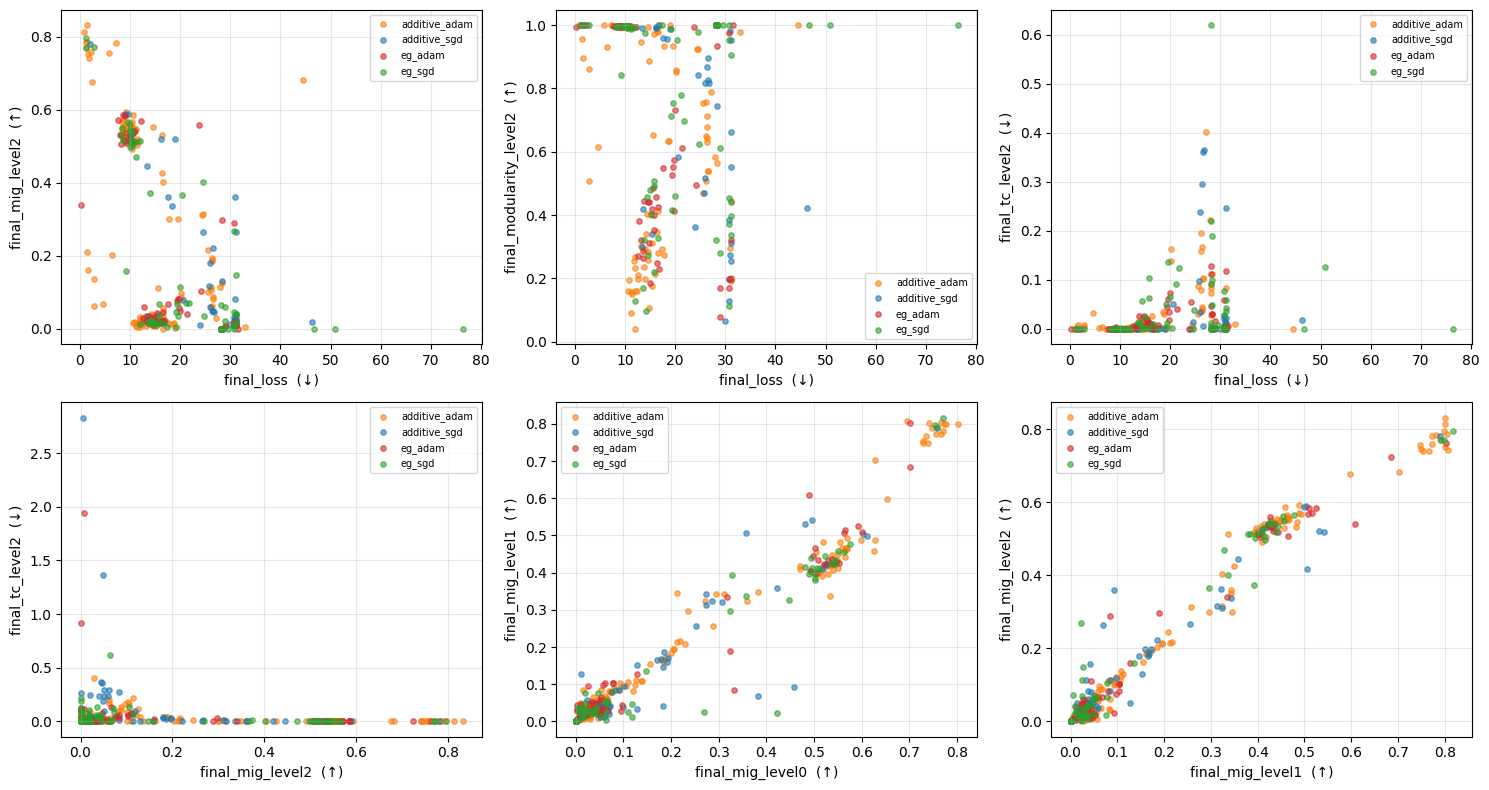

In [6]:
LOSS_PLOT_CAP = 100  # filter blow-up cells (one cell has loss ~22500) so the axis isn't squished

metric_pairs = [
    ("final_loss",              "final_mig_level2",        True,  False),
    ("final_loss",              "final_modularity_level2", True,  False),
    ("final_loss",              "final_tc_level2",         True,  True),
    ("final_mig_level2",        "final_tc_level2",         False, True),
    ("final_mig_level0",        "final_mig_level1",        False, False),  # train vs OOD disentanglement
    ("final_mig_level1",        "final_mig_level2",        False, False),  # hole vs full
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = {
    "additive_sgd":  "tab:blue",
    "additive_adam": "tab:orange",
    "eg_sgd":        "tab:green",
    "eg_adam":       "tab:red",
}
for ax, (xcol, ycol, x_low_good, y_low_good) in zip(axes.flat, metric_pairs):
    sub = df_ok.dropna(subset=[xcol, ycol])
    if xcol == "final_loss":
        sub = sub[sub[xcol] < LOSS_PLOT_CAP]
    if ycol == "final_loss":
        sub = sub[sub[ycol] < LOSS_PLOT_CAP]
    for combo, group in sub.groupby("outer_combo"):
        ax.scatter(group[xcol], group[ycol], c=colors.get(combo, "gray"), label=combo, s=15, alpha=0.6)
    ax.set_xlabel(f"{xcol}  ({'↓' if x_low_good else '↑'})")
    ax.set_ylabel(f"{ycol}  ({'↓' if y_low_good else '↑'})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=7)
plt.tight_layout(); plt.show()

## 4. Paired-comparison helper
For "does factor X matter?": for every combination of all *other* factors held fixed, look at the within-pair delta in each metric across the levels of X. Distribution of deltas tells you:
- centered at 0 → factor doesn't matter
- consistently positive/negative → factor matters and direction is clear
- scattered → factor matters but interacts with other factors

In [7]:
def paired_deltas(df_ok, vary_factor: str, metric_col: str, fixed_factors: list[str]):
    """For each unique combination of fixed_factors, find all pairs differing only in vary_factor; return their deltas in metric_col."""
    deltas = []
    for keys, group in df_ok.groupby(fixed_factors, dropna=False):
        levels = sorted(group[vary_factor].dropna().unique())
        if len(levels) < 2:
            continue
        for i in range(len(levels)):
            for j in range(i + 1, len(levels)):
                lo_rows = group[group[vary_factor] == levels[i]]
                hi_rows = group[group[vary_factor] == levels[j]]
                if lo_rows.empty or hi_rows.empty:
                    continue
                lo, hi = lo_rows.iloc[0], hi_rows.iloc[0]
                if pd.isna(lo[metric_col]) or pd.isna(hi[metric_col]):
                    continue
                deltas.append({
                    "lo_level": levels[i],
                    "hi_level": levels[j],
                    "lo_value": lo[metric_col],
                    "hi_value": hi[metric_col],
                    "delta":    hi[metric_col] - lo[metric_col],
                })
    return pd.DataFrame(deltas)

def summarize_factor(df_ok, vary_factor: str, fixed_factors: list[str]):
    print(f"\n=== factor: {vary_factor}  (holding fixed: {fixed_factors}) ===")
    for metric_col in METRIC_COLS:
        deltas = paired_deltas(df_ok, vary_factor, metric_col, fixed_factors)
        if deltas.empty:
            print(f"  {metric_col:30}  no paired comparisons")
            continue
        d = deltas["delta"]
        print(
            f"  {metric_col:30}  n={len(d):4}  median={d.median():+.4g}  mean={d.mean():+.4g}  "
            f"|delta|>0.01: {((d.abs() > 0.01).mean() * 100):.0f}%  hi>lo: {(d > 0).mean()*100:.0f}%"
        )

In [8]:
# does RTRL_beta matter? Fix every other factor.
summarize_factor(df_ok, vary_factor="rtrl_beta",
                 fixed_factors=["outer_combo", "target", "mlr", "b1", "beta_init", "meta2_beta"])


=== factor: rtrl_beta  (holding fixed: ['outer_combo', 'target', 'mlr', 'b1', 'beta_init', 'meta2_beta']) ===
  final_loss                      n= 130  median=-0.141  mean=+0.7617  |delta|>0.01: 98%  hi>lo: 44%
  final_mig_level0                n= 171  median=+0.003577  mean=+0.033  |delta|>0.01: 78%  hi>lo: 52%
  final_mig_level1                n= 171  median=+0  mean=+0.02125  |delta|>0.01: 78%  hi>lo: 48%
  final_mig_level2                n= 171  median=+0.0002537  mean=+0.0284  |delta|>0.01: 71%  hi>lo: 50%
  final_modularity_level0         n= 171  median=-0.003316  mean=-0.02742  |delta|>0.01: 73%  hi>lo: 42%
  final_modularity_level1         n= 171  median=-0.0001542  mean=-0.03459  |delta|>0.01: 73%  hi>lo: 42%
  final_modularity_level2         n= 171  median=-0.0006335  mean=-0.02411  |delta|>0.01: 67%  hi>lo: 39%
  final_tc_level0                 n= 171  median=-7.094e-06  mean=-0.02378  |delta|>0.01: 47%  hi>lo: 48%
  final_tc_level1                 n= 171  median=+2.771e-07

In [9]:
# does beta_init matter?
summarize_factor(df_ok, vary_factor="beta_init",
                 fixed_factors=["outer_combo", "target", "mlr", "b1", "rtrl_beta", "meta2_beta"])


=== factor: beta_init  (holding fixed: ['outer_combo', 'target', 'mlr', 'b1', 'rtrl_beta', 'meta2_beta']) ===


  final_loss                      n= 141  median=-3.43  mean=-168.2  |delta|>0.01: 95%  hi>lo: 26%
  final_mig_level0                n= 174  median=+0.4442  mean=+0.3336  |delta|>0.01: 90%  hi>lo: 82%
  final_mig_level1                n= 174  median=+0.3579  mean=+0.2924  |delta|>0.01: 91%  hi>lo: 83%
  final_mig_level2                n= 174  median=+0.4621  mean=+0.3427  |delta|>0.01: 91%  hi>lo: 82%
  final_modularity_level0         n= 174  median=+0.3224  mean=+0.3042  |delta|>0.01: 89%  hi>lo: 80%
  final_modularity_level1         n= 174  median=+0.2859  mean=+0.2999  |delta|>0.01: 87%  hi>lo: 79%
  final_modularity_level2         n= 174  median=+0.3674  mean=+0.35  |delta|>0.01: 89%  hi>lo: 79%
  final_tc_level0                 n= 174  median=-0.0133  mean=-0.02996  |delta|>0.01: 64%  hi>lo: 11%
  final_tc_level1                 n= 174  median=-0.02911  mean=-0.07567  |delta|>0.01: 78%  hi>lo: 26%
  final_tc_level2                 n= 174  median=-0.007874  mean=-0.03335  |delta|>0

In [10]:
# does meta2_beta (val_beta) matter?
summarize_factor(df_ok, vary_factor="meta2_beta",
                 fixed_factors=["outer_combo", "target", "mlr", "b1", "rtrl_beta", "beta_init"])


=== factor: meta2_beta  (holding fixed: ['outer_combo', 'target', 'mlr', 'b1', 'rtrl_beta', 'beta_init']) ===


  final_loss                      n= 138  median=+0.1799  mean=+169.5  |delta|>0.01: 97%  hi>lo: 55%
  final_mig_level0                n= 174  median=-0.008574  mean=-0.03699  |delta|>0.01: 73%  hi>lo: 34%
  final_mig_level1                n= 174  median=-0.007875  mean=-0.03538  |delta|>0.01: 73%  hi>lo: 37%
  final_mig_level2                n= 174  median=-0.006158  mean=-0.03681  |delta|>0.01: 75%  hi>lo: 40%
  final_modularity_level0         n= 174  median=-0.00159  mean=-0.01966  |delta|>0.01: 71%  hi>lo: 40%
  final_modularity_level1         n= 174  median=-0.000343  mean=-0.03807  |delta|>0.01: 73%  hi>lo: 41%
  final_modularity_level2         n= 174  median=-0.0005763  mean=-0.04772  |delta|>0.01: 66%  hi>lo: 39%
  final_tc_level0                 n= 174  median=-1.853e-05  mean=-0.03646  |delta|>0.01: 44%  hi>lo: 46%
  final_tc_level1                 n= 174  median=+0.0005148  mean=-0.006224  |delta|>0.01: 56%  hi>lo: 56%
  final_tc_level2                 n= 174  median=-4.66e-

In [11]:
# does the OHO target subset matter? — is adding wd to the target subset worth it,
# is adding lr to the target subset worth it (vs β-only)?
# target has 3 levels (β / β+lr / β+lr+wd) so paired_deltas yields one delta per pair of levels per fixed combo.
summarize_factor(df_ok, vary_factor="target",
                 fixed_factors=["outer_combo", "mlr", "b1", "rtrl_beta", "beta_init", "meta2_beta"])

# Drill into specific target pairs: did *adding wd* (over β+lr) help?
df_no_beta_only = df_ok[df_ok["target"].isin(["beta_lr", "beta_lr_wd"])]
print("\n=== β+lr  vs  β+lr+wd  (does adding wd help?) ===")
summarize_factor(df_no_beta_only, vary_factor="target",
                 fixed_factors=["outer_combo", "mlr", "b1", "rtrl_beta", "beta_init", "meta2_beta"])

# Did *adding lr* (over β-only) help?
df_no_full = df_ok[df_ok["target"].isin(["beta", "beta_lr"])]
print("\n=== β-only  vs  β+lr  (does adding lr help?) ===")
summarize_factor(df_no_full, vary_factor="target",
                 fixed_factors=["outer_combo", "mlr", "b1", "rtrl_beta", "beta_init", "meta2_beta"])


=== factor: target  (holding fixed: ['outer_combo', 'mlr', 'b1', 'rtrl_beta', 'beta_init', 'meta2_beta']) ===


  final_loss                      n= 252  median=-0.5949  mean=+94.26  |delta|>0.01: 100%  hi>lo: 45%
  final_mig_level0                n= 344  median=+0.005516  mean=-0.01104  |delta|>0.01: 84%  hi>lo: 55%
  final_mig_level1                n= 344  median=+0.006514  mean=+0.02065  |delta|>0.01: 84%  hi>lo: 54%
  final_mig_level2                n= 344  median=+0.003888  mean=-0.004227  |delta|>0.01: 84%  hi>lo: 54%
  final_modularity_level0         n= 344  median=+0.0285  mean=+0.1352  |delta|>0.01: 87%  hi>lo: 73%
  final_modularity_level1         n= 344  median=+0.02537  mean=+0.1546  |delta|>0.01: 88%  hi>lo: 73%
  final_modularity_level2         n= 344  median=+0.04589  mean=+0.1859  |delta|>0.01: 74%  hi>lo: 75%
  final_tc_level0                 n= 344  median=+3.022e-05  mean=+0.03213  |delta|>0.01: 50%  hi>lo: 55%
  final_tc_level1                 n= 344  median=+0.0001168  mean=+0.02399  |delta|>0.01: 57%  hi>lo: 50%
  final_tc_level2                 n= 344  median=+0.0001584  m

## 4b. Paired-comparison visualizations (absolute magnitude)
`summarize_factor` gives you the *sign* and median delta. These plots show *how much* a factor moves a metric in absolute units, so you can decide whether the effect is large enough to care about.

- **paired_scatter**: for each pair, plot (value at low level, value at high level). Points on the diagonal = no effect. Points far off the diagonal = big effect. Color = (lo, hi) pair.
- **boxplot_by_factor**: marginal distribution of each metric grouped by factor level (ignores pairing, but shows overall spread).

In [12]:
# --- visualization helpers for paired comparisons ---
DISP_METRICS = [
    ("final_loss",              True),
    ("final_mig_level2",        False),
    ("final_modularity_level2", False),
    ("final_tc_level2",         True),
]

def paired_scatter(df_ok, vary_factor: str, fixed_factors: list[str], metrics=DISP_METRICS, loss_cap: float = 100.0):
    """For each paired comparison, plot (lo_value, hi_value) so on-diagonal = no effect, off-diagonal = effect."""
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
    for ax, (metric_col, low_better) in zip(axes, metrics):
        deltas = paired_deltas(df_ok, vary_factor, metric_col, fixed_factors)
        if deltas.empty:
            ax.set_title(f"{metric_col}\n(no pairs)"); continue
        if metric_col == "final_loss":
            deltas = deltas[(deltas["lo_value"] < loss_cap) & (deltas["hi_value"] < loss_cap)]
        if deltas.empty:
            ax.set_title(f"{metric_col}\n(all > {loss_cap})"); continue
        for (lo_lvl, hi_lvl), grp in deltas.groupby(["lo_level", "hi_level"]):
            ax.scatter(grp["lo_value"], grp["hi_value"], s=15, alpha=0.6, label=f"{lo_lvl} → {hi_lvl}")
        lo = min(deltas["lo_value"].min(), deltas["hi_value"].min())
        hi = max(deltas["lo_value"].max(), deltas["hi_value"].max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.5, alpha=0.5)
        ax.set_xlabel(f"value at low {vary_factor}")
        ax.set_ylabel(f"value at high {vary_factor}")
        ax.set_title(f"{metric_col}  ({'↓' if low_better else '↑'})")
        ax.legend(fontsize=7, loc="best")
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"paired comparison: {vary_factor}", y=1.02)
    plt.tight_layout(); plt.show()

def boxplot_by_factor(df_ok, vary_factor: str, metrics=DISP_METRICS, loss_cap: float = 100.0):
    """Distribution of each metric by levels of vary_factor (every cell, not just paired)."""
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
    for ax, (metric_col, low_better) in zip(axes, metrics):
        sub = df_ok.dropna(subset=[metric_col, vary_factor]).copy()
        if metric_col == "final_loss":
            sub = sub[sub[metric_col] < loss_cap]
        if sub.empty:
            ax.set_title(f"{metric_col}\n(empty)"); continue
        levels = sorted(sub[vary_factor].unique())
        data = [sub[sub[vary_factor] == lvl][metric_col].values for lvl in levels]
        ax.boxplot(data, tick_labels=[str(l) for l in levels], showfliers=True)
        ax.set_xlabel(vary_factor)
        ax.set_ylabel(metric_col)
        ax.set_title(f"{metric_col}  ({'↓' if low_better else '↑'})")
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"distribution by {vary_factor}", y=1.02)
    plt.tight_layout(); plt.show()

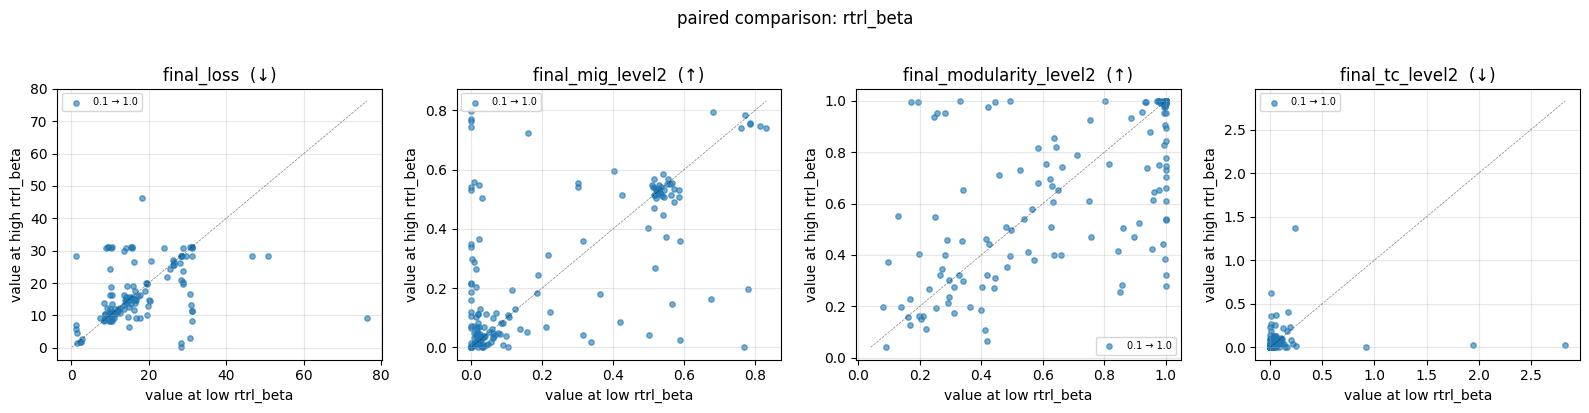

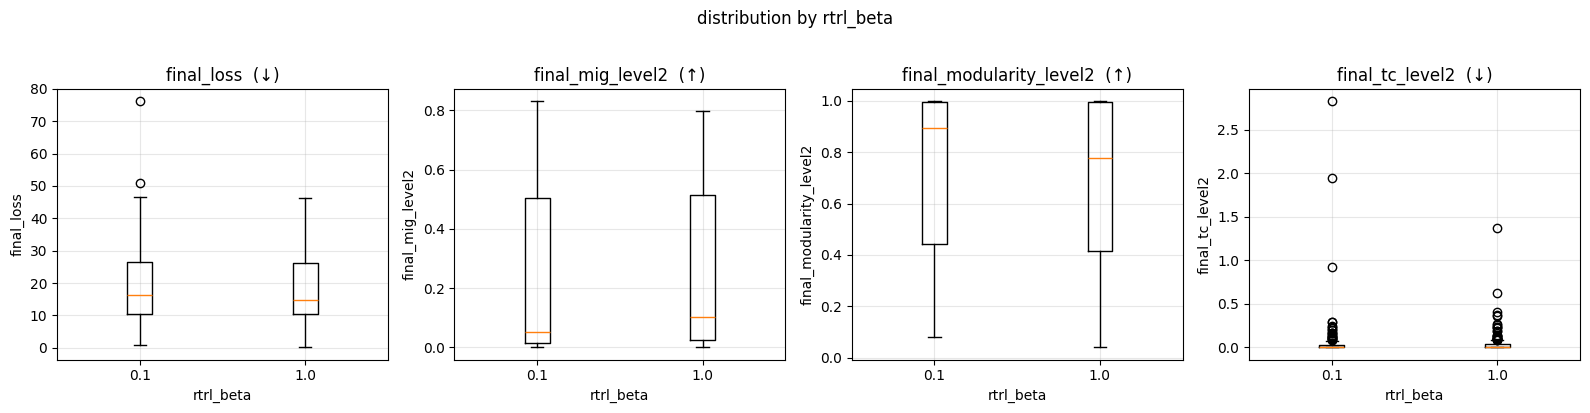

In [13]:
# rtrl_beta — does damping the hypergradient running average matter?
paired_scatter(df_ok, vary_factor="rtrl_beta",
               fixed_factors=["outer_combo", "target", "mlr", "b1", "beta_init", "meta2_beta"])
boxplot_by_factor(df_ok, vary_factor="rtrl_beta")

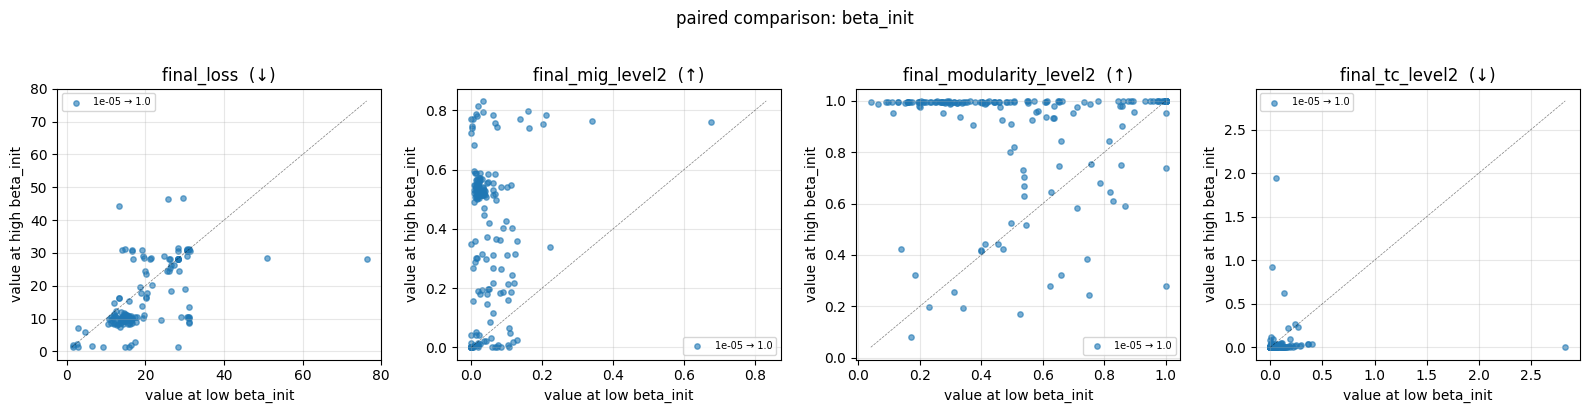

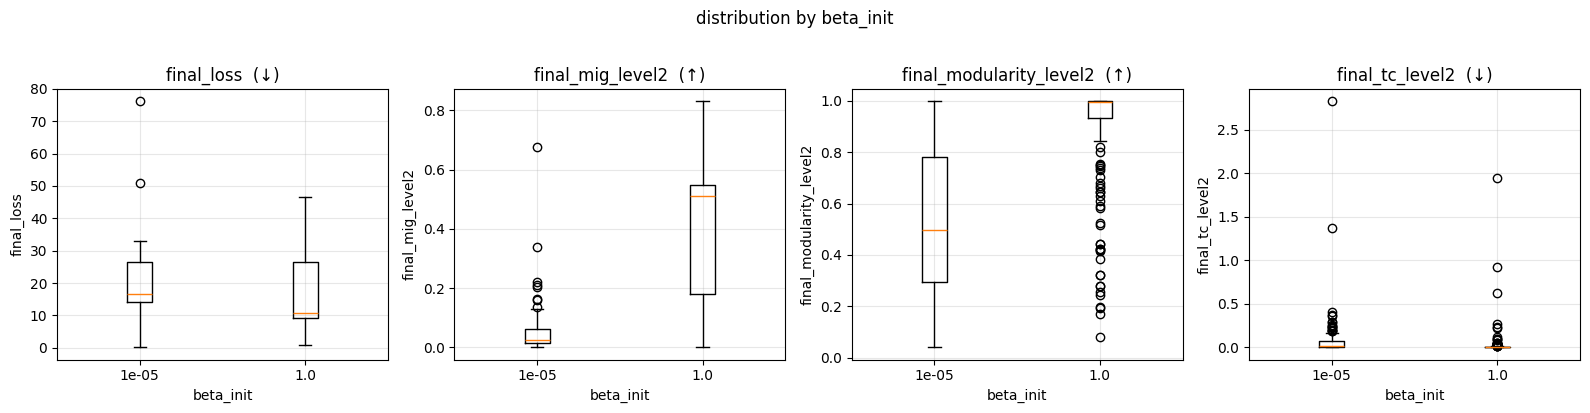

In [14]:
# beta_init — the dominant factor in the rankings; quantify the gap
paired_scatter(df_ok, vary_factor="beta_init",
               fixed_factors=["outer_combo", "target", "mlr", "b1", "rtrl_beta", "meta2_beta"])
boxplot_by_factor(df_ok, vary_factor="beta_init")

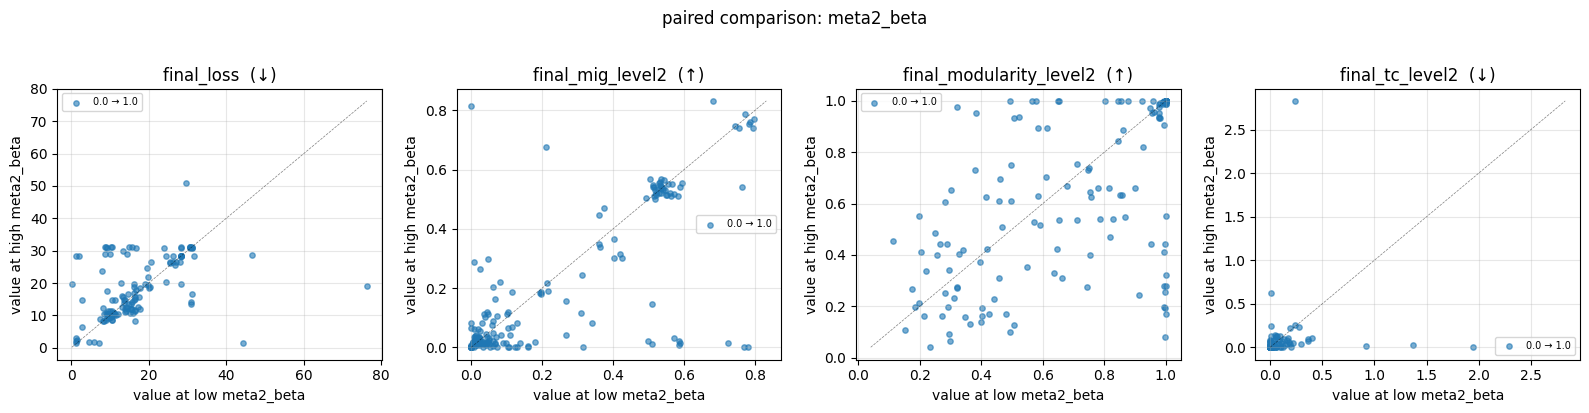

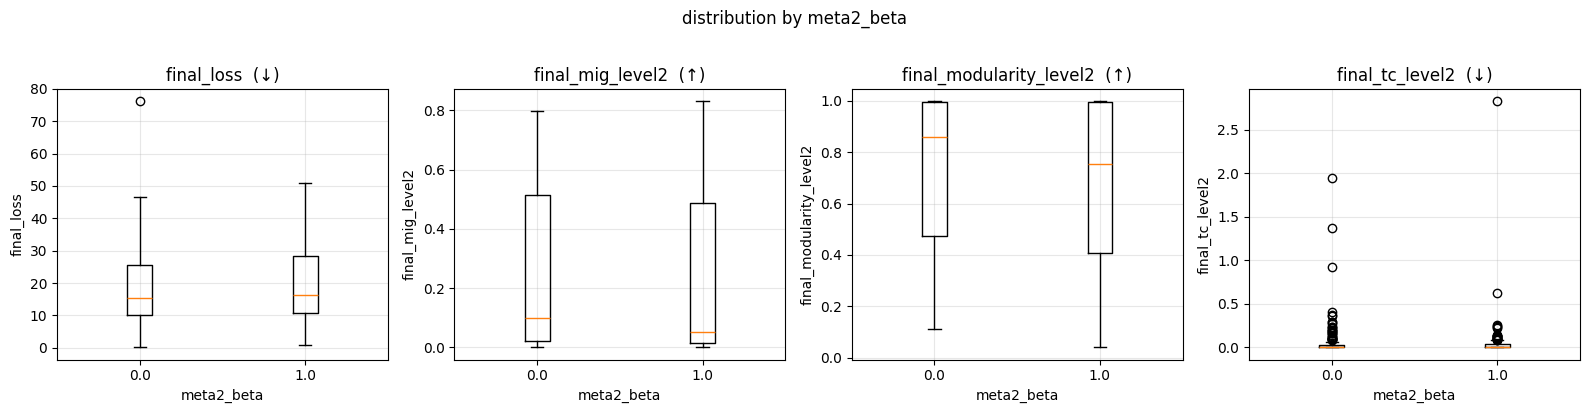

In [15]:
# meta2_beta (validation beta) — does the val ELBO weighting matter?
paired_scatter(df_ok, vary_factor="meta2_beta",
               fixed_factors=["outer_combo", "target", "mlr", "b1", "rtrl_beta", "beta_init"])
boxplot_by_factor(df_ok, vary_factor="meta2_beta")

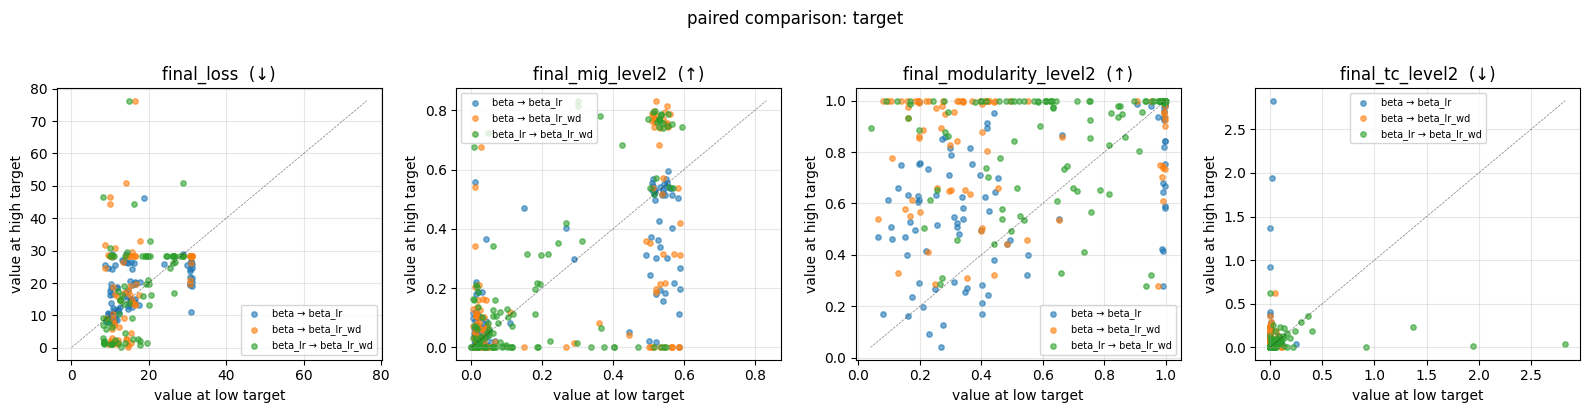

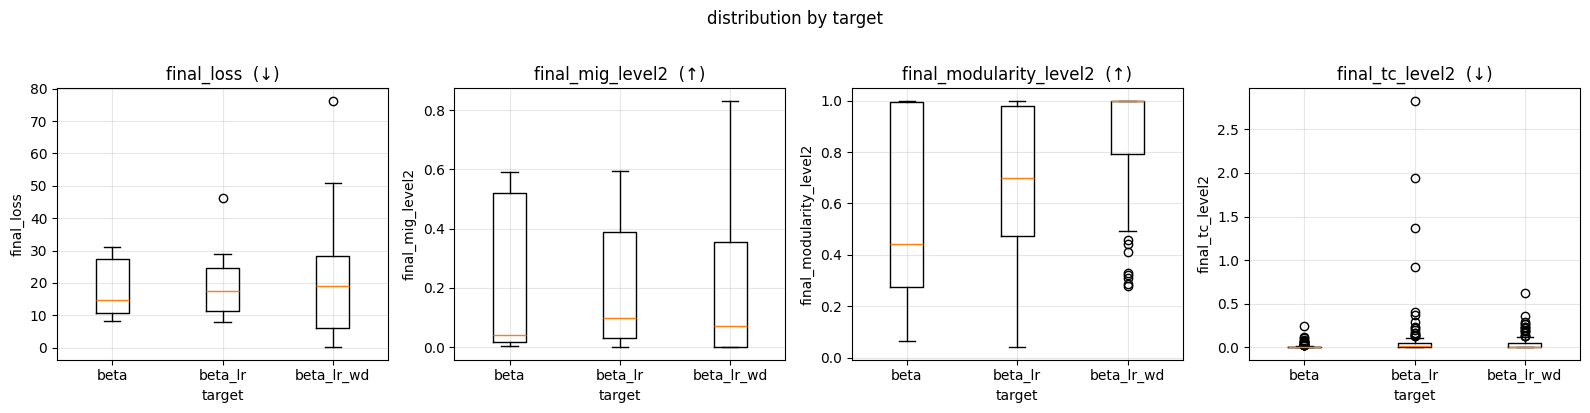

In [16]:
# target — OHO subset (β / β+lr / β+lr+wd). 3 levels so legend shows the 3 pairs.
paired_scatter(df_ok, vary_factor="target",
               fixed_factors=["outer_combo", "mlr", "b1", "rtrl_beta", "beta_init", "meta2_beta"])
boxplot_by_factor(df_ok, vary_factor="target")

## 4c. Does Adam momentum (b1) matter?
b1 only varies for `additive_adam` (other outers don't use Adam momentum the same way). Filter to additive_adam, then ask: does b1 ∈ {0.0, 0.9, 0.99} matter?

additive_adam cells: 144
b1 levels present: [np.float64(0.9), np.float64(0.99)]

=== factor: b1  (holding fixed: ['target', 'mlr', 'rtrl_beta', 'beta_init', 'meta2_beta']) ===
  final_loss                      n=  63  median=+0.001087  mean=-9.164  |delta|>0.01: 94%  hi>lo: 52%
  final_mig_level0                n=  72  median=+0  mean=+0.01297  |delta|>0.01: 67%  hi>lo: 49%
  final_mig_level1                n=  72  median=-0.005918  mean=+0.006917  |delta|>0.01: 65%  hi>lo: 40%
  final_mig_level2                n=  72  median=-0.001151  mean=+0.008551  |delta|>0.01: 71%  hi>lo: 46%
  final_modularity_level0         n=  72  median=+0.0002074  mean=+0.00103  |delta|>0.01: 64%  hi>lo: 53%
  final_modularity_level1         n=  72  median=-0.0009362  mean=-0.01354  |delta|>0.01: 62%  hi>lo: 35%
  final_modularity_level2         n=  72  median=-8.643e-07  mean=+0.002037  |delta|>0.01: 51%  hi>lo: 47%
  final_tc_level0                 n=  72  median=+1.178e-05  mean=+0.01661  |delta|>0.01: 31

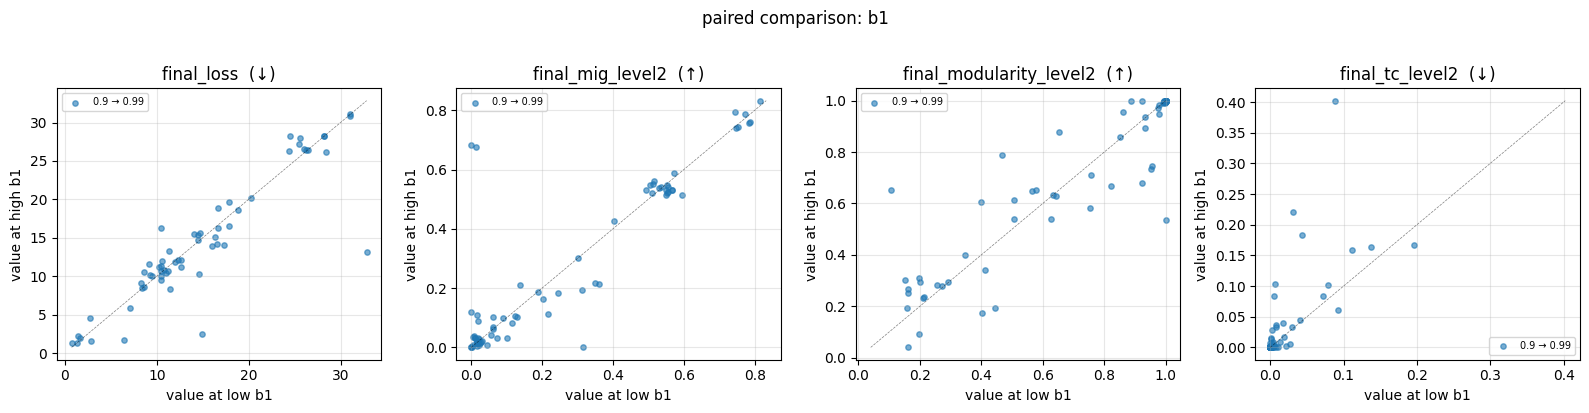

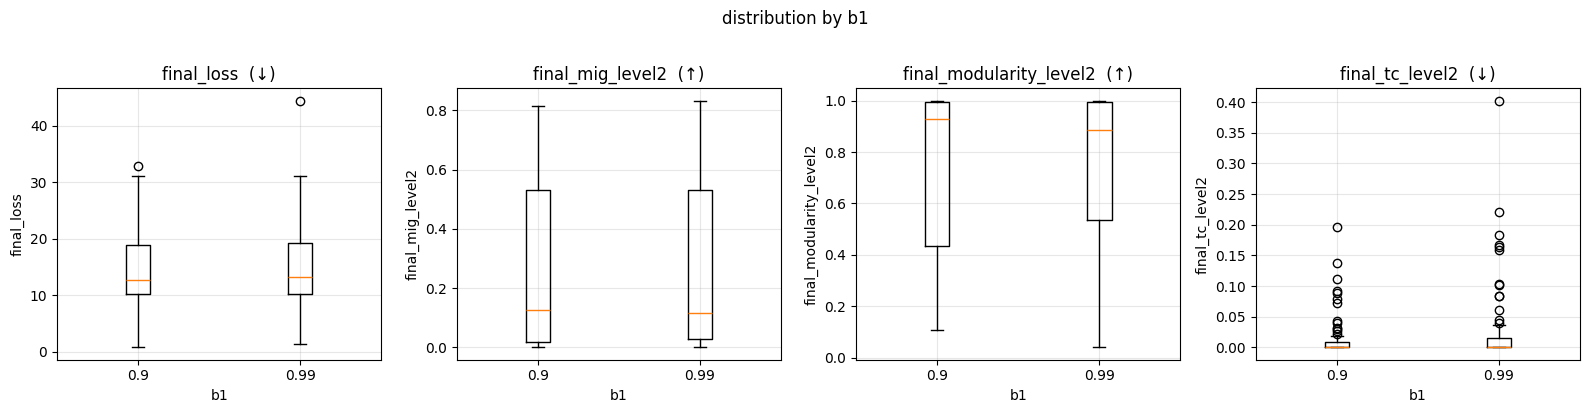

In [17]:
df_adam = df_ok[df_ok["outer_combo"] == "additive_adam"].copy()
print(f"additive_adam cells: {len(df_adam)}")
print(f"b1 levels present: {sorted(df_adam['b1'].dropna().unique())}")

summarize_factor(df_adam, vary_factor="b1",
                 fixed_factors=["target", "mlr", "rtrl_beta", "beta_init", "meta2_beta"])
paired_scatter(df_adam, vary_factor="b1",
               fixed_factors=["target", "mlr", "rtrl_beta", "beta_init", "meta2_beta"])
boxplot_by_factor(df_adam, vary_factor="b1")

## 5. NaN-abort distribution per factor
Which factor levels produced disproportionate NaN failures? "This setting is a stability landmine" is often a more actionable finding than "this setting wins."

In [18]:
for col in ("outer_combo", "target", "rtrl_beta", "mlr", "b1", "beta_init", "meta2_beta"):
    counts = df.groupby(col, dropna=False)["aborted"].agg(["sum", "count"])
    counts["abort_rate"] = counts["sum"] / counts["count"]
    print(f"\n--- abort rate by {col} ---")
    print(counts.to_string())


--- abort rate by outer_combo ---
               sum  count  abort_rate
outer_combo                          
additive_adam    0    144    0.000000
additive_sgd    10     72    0.138889
eg_adam          0     72    0.000000
eg_sgd           0     72    0.000000

--- abort rate by target ---
            sum  count  abort_rate
target                            
beta          0    120    0.000000
beta_lr       5    120    0.041667
beta_lr_wd    5    120    0.041667

--- abort rate by rtrl_beta ---
           sum  count  abort_rate
rtrl_beta                        
0.1          1    180    0.005556
1.0          9    180    0.050000

--- abort rate by mlr ---
          sum  count  abort_rate
mlr                             
0.000001    0     24    0.000000
0.000010    0     96    0.000000
0.000100    1    120    0.008333
0.001000    9     96    0.093750
0.010000    0     24    0.000000

--- abort rate by b1 ---
      sum  count  abort_rate
b1                          
0.00   10    144    0

## 6. Trajectory inspector for chosen cells
Once you've picked promising cells from the rankings, plot β, lr, wd trajectories to see what OHO actually did. Use this to answer questions like "did OHO drive β to the same place from different starts" (= robust) vs "did β stay at init" (= OHO did nothing meaningful).

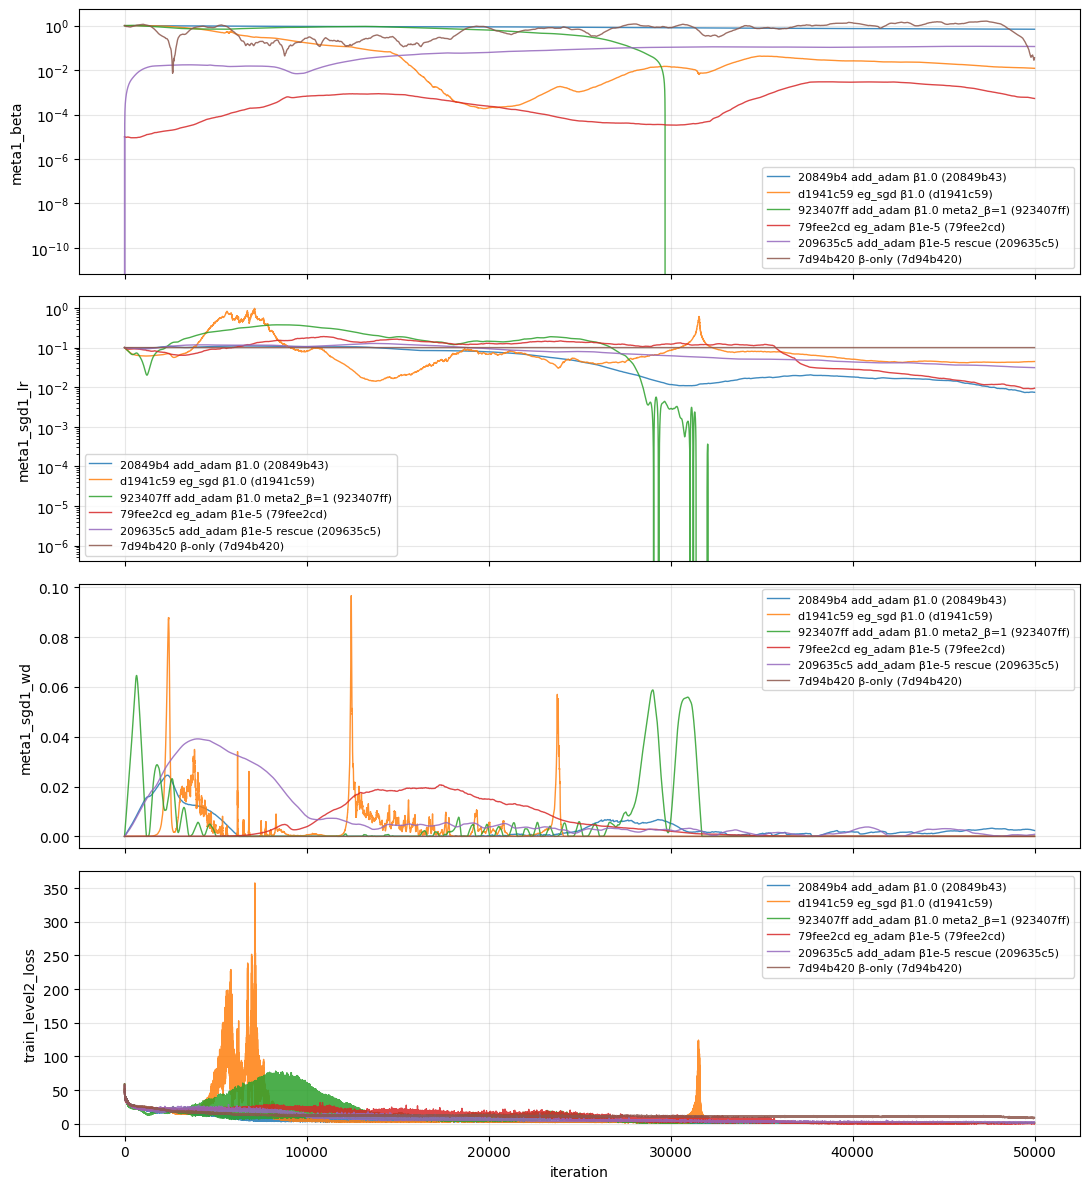

In [23]:
TRAJECTORY_PATHS = {
    "meta1_beta":        "train/level1/kl_regularizer_beta/meta1_beta/0/0/0/0",
    "meta1_sgd1_lr":     "train/level1/learning_rate/meta1_sgd1_lr/0/0/0/0",
    "meta1_sgd1_wd":     "train/level1/weight_decay/meta1_sgd1_wd/0/0/0/0",
    "train_level2_loss": "train/level2/loss/0/0/0",
}

def plot_trajectories(task_ids: list[str], titles: list[str] | None = None):
    titles = titles or task_ids
    fig, axes = plt.subplots(len(TRAJECTORY_PATHS), 1, figsize=(11, 3 * len(TRAJECTORY_PATHS)), sharex=True)
    cmap = plt.get_cmap("tab10")
    for ti, (tid, title) in enumerate(zip(task_ids, titles)):
        h5 = find_h5(tid)
        if h5 is None:
            print(f"no h5 for {tid[:8]}"); continue
        with h5py.File(h5, "r") as f:
            for ax, (name, path) in zip(axes, TRAJECTORY_PATHS.items()):
                if path not in f:
                    continue
                vals = f[path][:]
                iters = f[f"{path}_iterations"][:]
                m = (iters >= 0) & np.isfinite(vals)
                ax.plot(iters[m], vals[m], color=cmap(ti % 10), linewidth=1, alpha=0.85,
                        label=f"{title} ({tid[:8]})")
                ax.set_ylabel(name); ax.grid(True, alpha=0.3)
    for ax in axes:
        ax.legend(loc="best", fontsize=8)
    axes[0].set_yscale("log")  # β
    axes[1].set_yscale("log")  # lr
    axes[-1].set_xlabel("iteration")
    plt.tight_layout(); plt.show()

# All candidate cells we've discussed — see if their trajectories look smooth + purposeful
plot_trajectories(
    ["20849b4381ca4e41973dea94e1dd7f2f",  # additive_adam β+lr+wd β_init=1.0 (top safe pick)
     "d1941c593f4a4305bf5bad3a054b6e83",  # eg_sgd β+lr+wd β_init=1.0 (alt)
     "923407ff64b947bd86713c6ec48cb6d1",  # additive_adam β+lr+wd β_init=1.0 meta2_β=1 (cross-axis)
     "79fee2cd8afc4f2fb6b7ca132d35151f",  # eg_adam β_init=1e-5 (rotated grid)
     "209635c5e3dd4f53a42c57cedb4f5e95",  # additive_adam β_init=1e-5 rescue
     "7d94b420834141108884dfe46cf553f1"], # β-only ceiling
    ["20849b4 add_adam β1.0",
     "d1941c59 eg_sgd β1.0",
     "923407ff add_adam β1.0 meta2_β=1",
     "79fee2cd eg_adam β1e-5",
     "209635c5 add_adam β1e-5 rescue",
     "7d94b420 β-only"],
)

## 7. β-only vs β+lr+wd saturation check
Plot training-loss + MIG + β trajectories side-by-side for the best β-only cell (`7d94b420`) vs the best β+lr+wd cell (`20849b4`) under the same outer config (meta2_beta=0, β_init=1.0, additive_adam, rtrl_beta=0.1, b1=0.9). If β-only's loss is still falling at the last iteration, training didn't saturate and a longer run could close the gap.

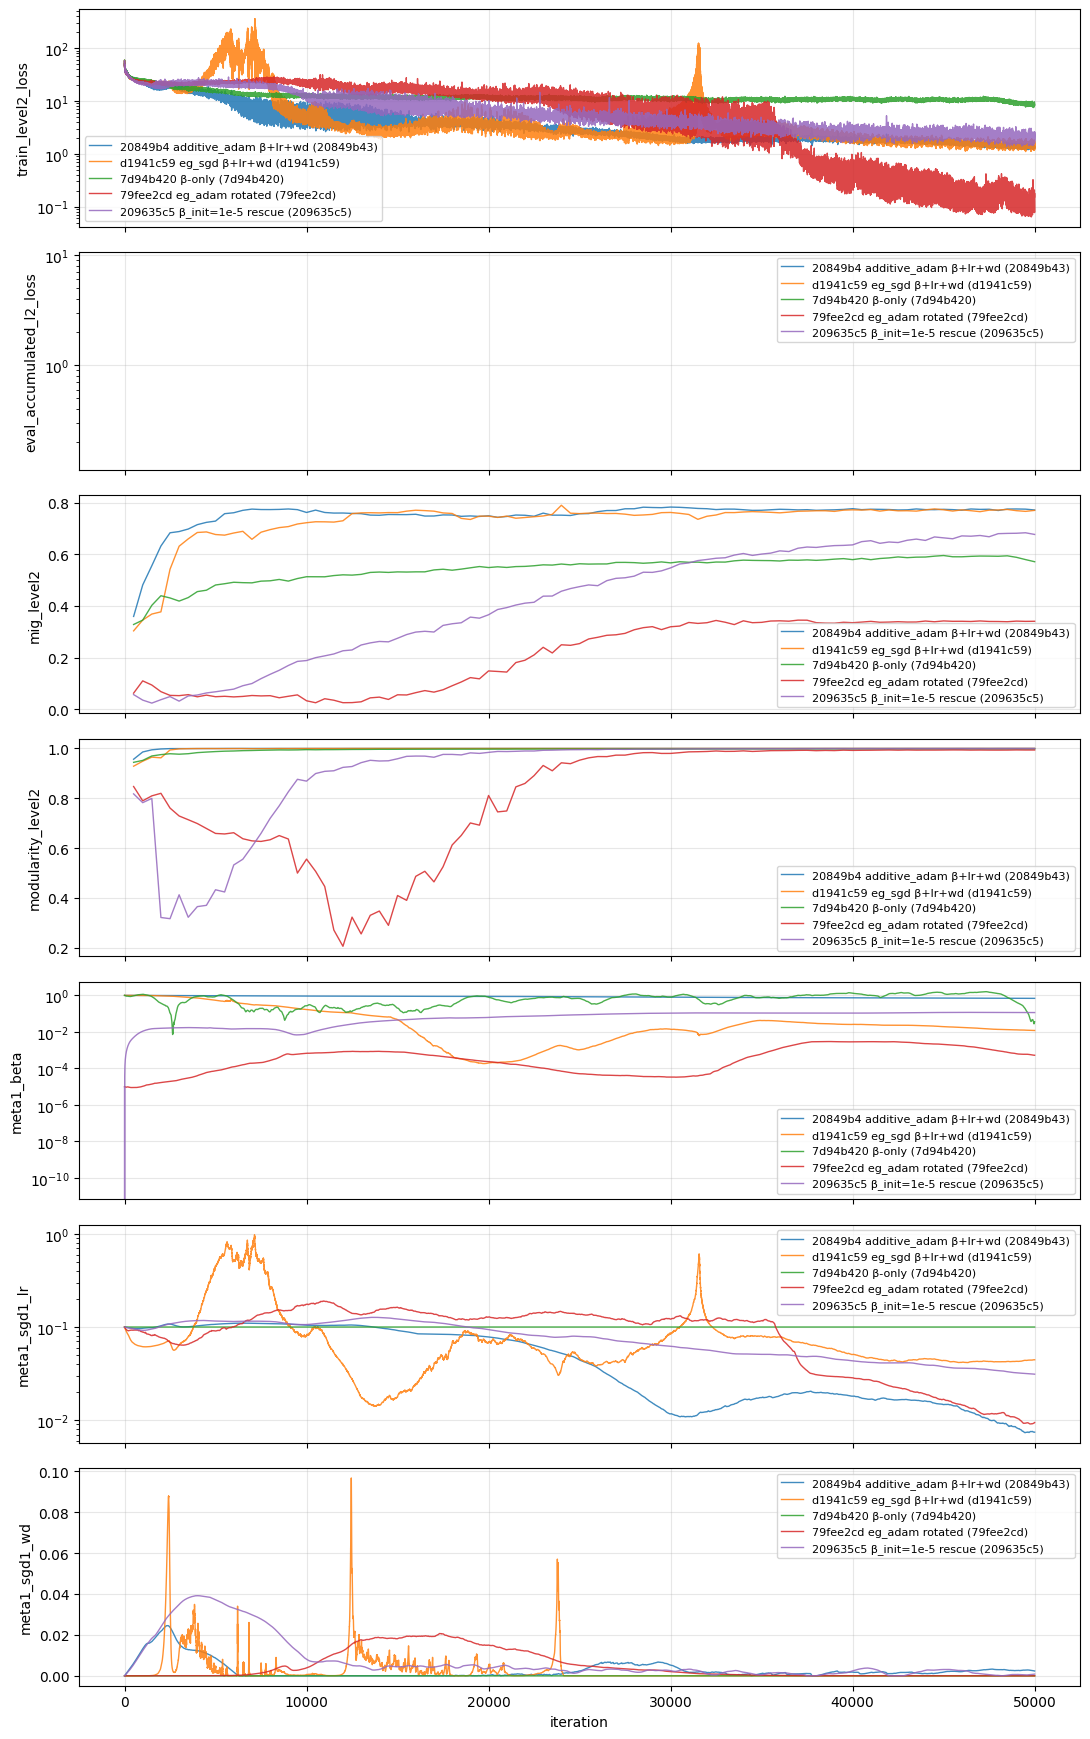

In [20]:
SATURATION_PATHS = {
    "train_level2_loss":         "train/level2/loss/0/0/0",
    "eval_accumulated_l2_loss":  "eval_accumulated/level2/loss/0/0/0",
    "mig_level2":                "disentanglement/level2/mig",
    "modularity_level2":         "disentanglement/level2/modularity",
    "meta1_beta":                "train/level1/kl_regularizer_beta/meta1_beta/0/0/0/0",
    "meta1_sgd1_lr":             "train/level1/learning_rate/meta1_sgd1_lr/0/0/0/0",
    "meta1_sgd1_wd":             "train/level1/weight_decay/meta1_sgd1_wd/0/0/0/0",
}

def plot_saturation(task_ids: list[str], titles: list[str]):
    fig, axes = plt.subplots(len(SATURATION_PATHS), 1,
                             figsize=(11, 2.5 * len(SATURATION_PATHS)), sharex=True)
    cmap = plt.get_cmap("tab10")
    for ti, (tid, title) in enumerate(zip(task_ids, titles)):
        h5 = find_h5(tid)
        if h5 is None:
            print(f"no h5 for {tid[:8]}"); continue
        with h5py.File(h5, "r") as f:
            for ax, (name, path) in zip(axes, SATURATION_PATHS.items()):
                if path not in f:
                    continue
                vals = f[path][:]
                iters = f[f"{path}_iterations"][:]
                m = (iters >= 0) & np.isfinite(vals)
                ax.plot(iters[m], vals[m], color=cmap(ti % 10),
                        linewidth=1, alpha=0.85, label=f"{title} ({tid[:8]})")
                ax.set_ylabel(name)
                ax.grid(True, alpha=0.3)
    for ax in axes:
        ax.legend(loc="best", fontsize=8)
    axes[0].set_yscale("log")  # train loss
    axes[1].set_yscale("log")  # eval_accumulated loss
    axes[4].set_yscale("log")  # beta
    axes[5].set_yscale("log")  # lr
    axes[-1].set_xlabel("iteration")
    plt.tight_layout(); plt.show()

plot_saturation(
    ["20849b4381ca4e41973dea94e1dd7f2f",  # additive_adam β+lr+wd winner
     "d1941c593f4a4305bf5bad3a054b6e83",  # eg_sgd β+lr+wd alternative
     "7d94b420834141108884dfe46cf553f1",  # β-only — shows the ceiling
     "79fee2cd8afc4f2fb6b7ca132d35151f",  # EG(Adam) low loss + rotated latents
     "209635c5e3dd4f53a42c57cedb4f5e95"], # β_init=1e-5 rescue
    ["20849b4 additive_adam β+lr+wd",
     "d1941c59 eg_sgd β+lr+wd",
     "7d94b420 β-only",
     "79fee2cd eg_adam rotated",
     "209635c5 β_init=1e-5 rescue"],
)

## 8. Latent + reconstruction side-by-side: β-only vs β+lr+wd
Images logged offline to `LOG_DIR/images_{task_id}/{series_key}_{iter}.png` (NOT clearml). Pull the final-iter image for each key series and render β-only vs β+lr+wd in a 2-row grid so you can eyeball whether the latents look meaningfully different.

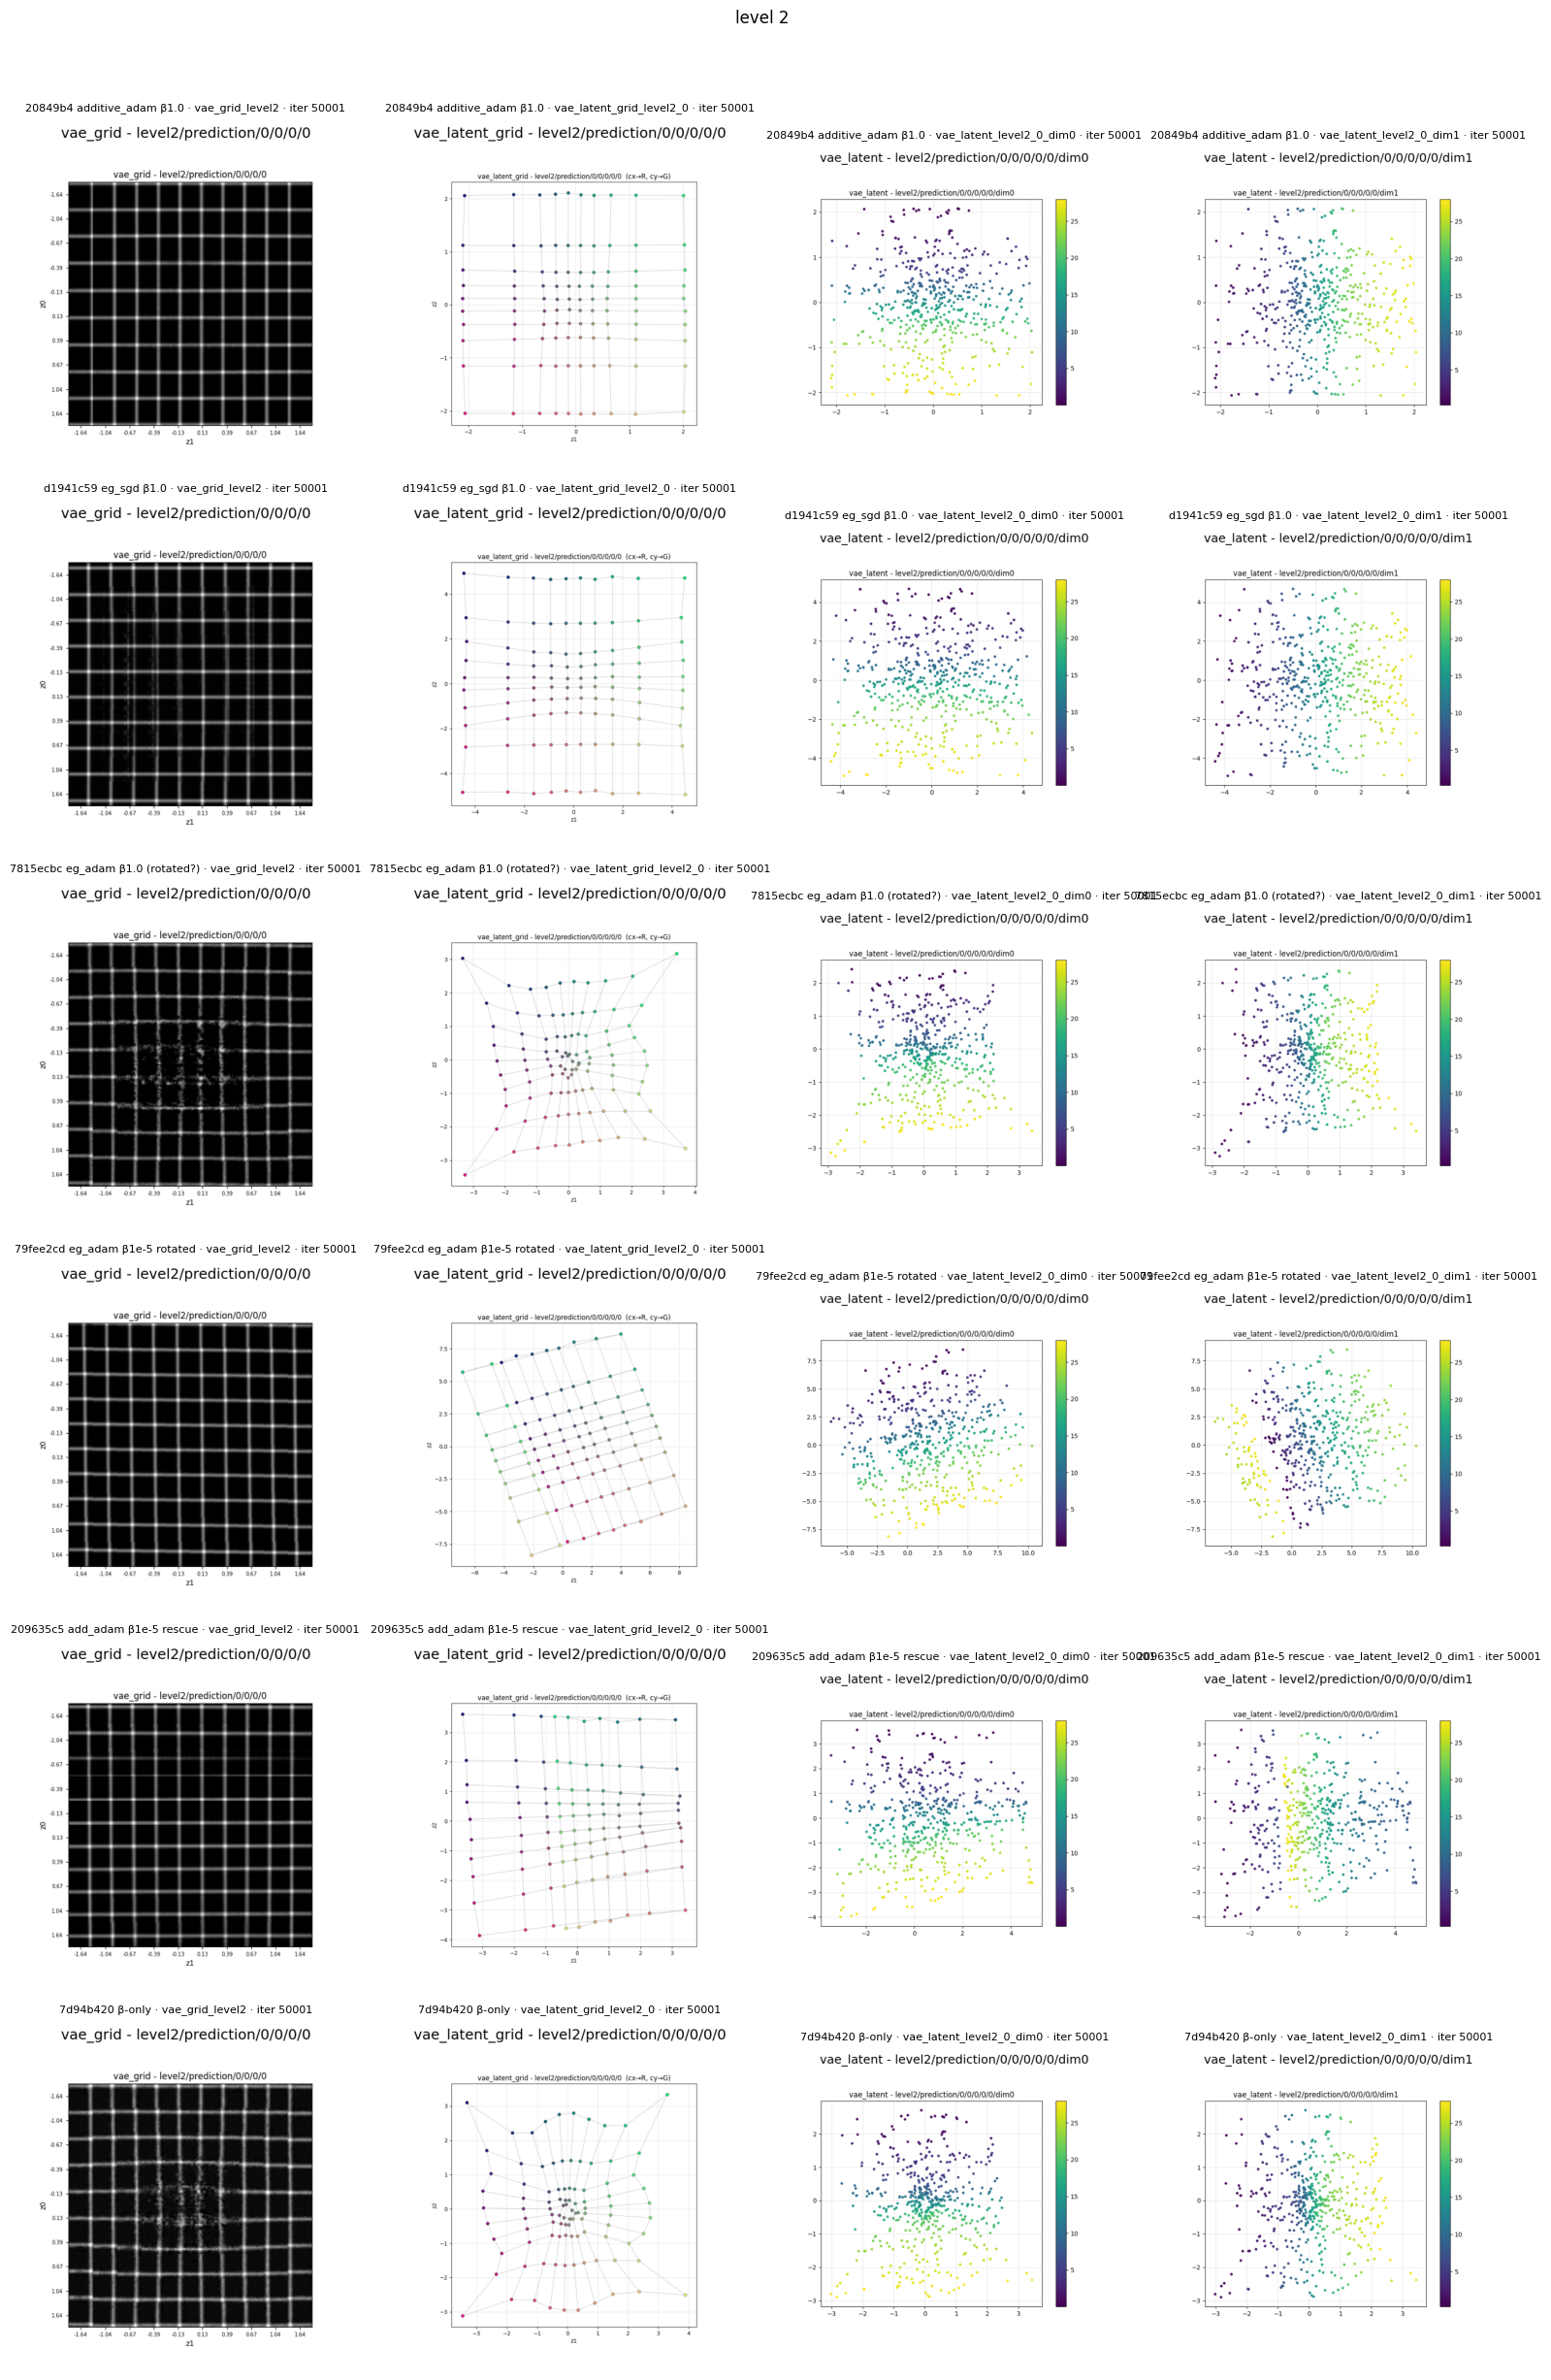

In [22]:
import re
from PIL import Image

def final_image(task_id: str, series_key: str) -> tuple[int, Path] | None:
    d = LOG_DIR / f"images_{task_id}"
    if not d.exists():
        return None
    best = None
    for p in d.glob(f"{series_key}_*.png"):
        m = re.match(rf"{re.escape(series_key)}_(\d+)\.png$", p.name)
        if m is None:
            continue
        it = int(m.group(1))
        if best is None or it > best[0]:
            best = (it, p)
    return best

def series_for_level(level: int) -> list[str]:
    return [
        f"vae_grid_level{level}_prediction_0_0_0_0",
        f"vae_latent_grid_level{level}_prediction_0_0_0_0_0",
        f"vae_latent_level{level}_prediction_0_0_0_0_0_dim0",
        f"vae_latent_level{level}_prediction_0_0_0_0_0_dim1",
    ]

def compare_latents(task_ids: list[str], titles: list[str], level: int):
    series = series_for_level(level)
    fig, axes = plt.subplots(len(task_ids), len(series),
                             figsize=(4 * len(series), 4 * len(task_ids)))
    if len(task_ids) == 1:
        axes = axes[None, :]
    for ri, (tid, title) in enumerate(zip(task_ids, titles)):
        for ci, key in enumerate(series):
            ax = axes[ri, ci]
            result = final_image(tid, key)
            if result is None:
                ax.text(0.5, 0.5, f"missing\n{key}", ha="center", va="center")
                ax.axis("off"); continue
            it, path = result
            ax.imshow(np.asarray(Image.open(path)))
            ax.set_title(f"{title} · {key.replace('_prediction_0_0_0_0','')} · iter {it}", fontsize=8)
            ax.axis("off")
    fig.suptitle(f"level {level}", y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()

TASKS  = ["20849b4381ca4e41973dea94e1dd7f2f",  # additive_adam β+lr+wd, β_init=1.0, MIG=0.77 (axis-aligned baseline)
          "d1941c593f4a4305bf5bad3a054b6e83",  # eg_sgd β+lr+wd, β_init=1.0, MIG=0.77 (alt baseline)
          "7815ecbcc0744fe29b9b246ff71f0e44",  # eg_adam β+lr+wd, β_init=1.0, MIG=0.57 (is it rotated or undertrained?)
          "79fee2cd8afc4f2fb6b7ca132d35151f",  # eg_adam β+lr+wd, β_init=1e-5, MIG=0.34 (known rotated)
          "209635c5e3dd4f53a42c57cedb4f5e95",  # additive_adam β+lr+wd, β_init=1e-5, MIG=0.68 (lone rescue)
          "7d94b420834141108884dfe46cf553f1"]  # β-only ceiling
TITLES = ["20849b4 additive_adam β1.0",
          "d1941c59 eg_sgd β1.0",
          "7815ecbc eg_adam β1.0 (rotated?)",
          "79fee2cd eg_adam β1e-5 rotated",
          "209635c5 add_adam β1e-5 rescue",
          "7d94b420 β-only"]

compare_latents(TASKS, TITLES, level=2)